Data structure:
sleep-edf-database-expanded-1.0.0/
├── sleep-cassette/
│   ├── SC4001E0-PSG.edf
│   ├── SC4001EC-Hypnogram.edf
│   ├── SC4002E0-PSG.edf
│   ├── SC4002EC-Hypnogram.edf
│   ├── ...
└── sleep-telemetry/
    ├── ST7001E0-PSG.edf
    ├── ST7001EC-Hypnogram.edf
    ├── ST7002E0-PSG.edf
    ├── ST7002EC-Hypnogram.edf
    ├── ...

Folder sleep-cassette thường là dữ liệu ghi tại nhà (ambulatory) với các bản ghi dài.
Folder sleep-telemetry: Thường là dữ liệu truyền từ xa trong phòng thí nghiệm.

File SC4001E0-PSG.edf là sóng, còn file SC4001EC-Hypnogram.edf mới là nhãn (kết quả bác sĩ đã đọc)

File information:
- his_id: X, sex: 2, first_name: Female, last_name: 33yr
- nchan: 7 (Kenh), sfreq: 100Hz (Tan so moi giay), Duration: 79,500 giây (22 gio)
    - EEG Fpz-Cz: Điện não đồ (vùng trán) - Xác định giấc ngủ nông/sâu qua sóng Delta, Theta, hay các k-complex.
    - EEG Pz-Oz: Điện não đồ (vùng chẩm) - Rất quan trọng để thấy sóng Alpha khi người bệnh nhắm mắt nhưng còn thức.
    - EOG horizontal: Điện nhãn đồ - Đo chuyển động mắt. Cần thiết để xác định giai đoạn REM (mắt đảo nhanh).
    - EMG submental: Điện cơ (dưới cằm) - Đo trương lực cơ. Trong giai đoạn REM, cơ bắp sẽ bị "liệt" hoàn toàn (điện cơ phẳng).
    - Resp oro-nasal: Hô hấp (mũi-miệng) - Theo dõi nhịp thở, dùng để phát hiện ngưng thở khi ngủ.
    - Temp rectal: Nhiệt độ trực tràng - Theo dõi sự thay đổi thân nhiệt trong chu kỳ sinh học.
    - Event marker: Đánh dấu sự kiện - Các ghi chú của kỹ thuật viên hoặc máy trong lúc đo.

Extracting EDF parameters from /Users/nguyenle/Desktop/tmu/advance computer programming/sleep_stage_classification/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
Raw data info:
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: 4 items (dict)
>

Annotations info:
<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>
Using matplotlib as 2D backend.


/var/folders/l0/ldvtdl8d4h54k4qpgmg_hfp00000gn/T/ipykernel_11098/2524055881.py:22: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


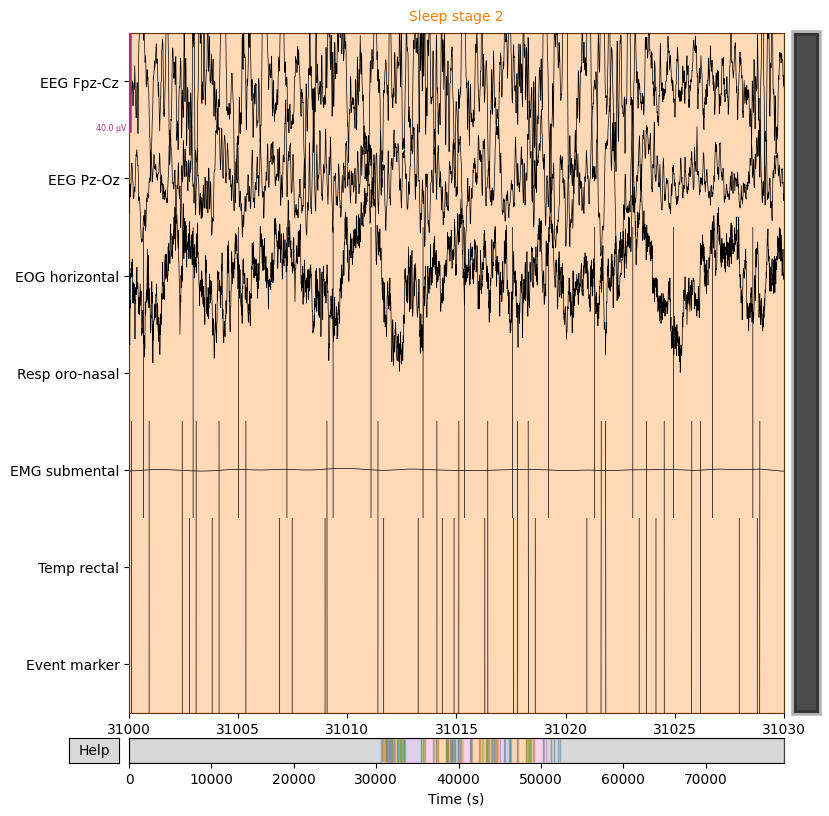

In [2]:
import mne
import matplotlib.pyplot as plt

origin_folder_path = 'sleep-edf-database-expanded-1.0.0'
cassette_folder_path = 'sleep-cassette'
telemetry_folder_path = 'sleep-telemetry'

# Test code to load and visualize the data
try:
    # 1. Load file sóng
    raw = mne.io.read_raw_edf(origin_folder_path + '/' + cassette_folder_path + '/SC4001E0-PSG.edf', preload=True)

    # 2. Load file nhãn (Hypnogram)
    annot = mne.read_annotations(origin_folder_path + '/' + cassette_folder_path + '/SC4001EC-Hypnogram.edf')

    print("Raw data info:")
    print(raw.info)
    print("\nAnnotations info:")
    print(annot)

    # 3. Gán nhãn vào sóng
    raw.set_annotations(annot)

    # Xem đoạn giây thứ 31000 để thấy sự thay đổi nhãn rõ rệt
    raw.plot(start=31000, duration=30)
except FileNotFoundError as e:
    print(f"Error: {e}. Please check if the file paths are correct and the files exist.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
# List filenames in folders
import os

cassette_files = os.listdir(origin_folder_path + '/' + cassette_folder_path)
cassette_files.sort()
telemetry_files = os.listdir(origin_folder_path + '/' + telemetry_folder_path)
telemetry_files.sort()
print("Files in cassette folder:")
print(cassette_files)
print("\nFiles in telemetry folder:")
print(telemetry_files)

Files in cassette folder:
['SC4001E0-PSG.edf', 'SC4001EC-Hypnogram.edf', 'SC4002E0-PSG.edf', 'SC4002EC-Hypnogram.edf', 'SC4011E0-PSG.edf', 'SC4011EH-Hypnogram.edf', 'SC4012E0-PSG.edf', 'SC4012EC-Hypnogram.edf', 'SC4021E0-PSG.edf', 'SC4021EH-Hypnogram.edf', 'SC4022E0-PSG.edf', 'SC4022EJ-Hypnogram.edf', 'SC4031E0-PSG.edf', 'SC4031EC-Hypnogram.edf', 'SC4032E0-PSG.edf', 'SC4032EP-Hypnogram.edf', 'SC4041E0-PSG.edf', 'SC4041EC-Hypnogram.edf', 'SC4042E0-PSG.edf', 'SC4042EC-Hypnogram.edf', 'SC4051E0-PSG.edf', 'SC4051EC-Hypnogram.edf', 'SC4052E0-PSG.edf', 'SC4052EC-Hypnogram.edf', 'SC4061E0-PSG.edf', 'SC4061EC-Hypnogram.edf', 'SC4062E0-PSG.edf', 'SC4062EC-Hypnogram.edf', 'SC4071E0-PSG.edf', 'SC4071EC-Hypnogram.edf', 'SC4072E0-PSG.edf', 'SC4072EH-Hypnogram.edf', 'SC4081E0-PSG.edf', 'SC4081EC-Hypnogram.edf', 'SC4082E0-PSG.edf', 'SC4082EP-Hypnogram.edf', 'SC4091E0-PSG.edf', 'SC4091EC-Hypnogram.edf', 'SC4092E0-PSG.edf', 'SC4092EC-Hypnogram.edf', 'SC4101E0-PSG.edf', 'SC4101EC-Hypnogram.edf', 'SC4102

1. Phân tách các dải sóng (Delta, Theta, Alpha, Beta)
Đây là phương pháp quan trọng nhất cho kênh EEG. Bạn sẽ sử dụng kỹ thuật Power Spectral Density (PSD) để tính công suất của từng dải sóng.

Sóng Delta (0.5 - 4 Hz): Đặc trưng cho giấc ngủ sâu (Stage N3).

Sóng Theta (4 - 8 Hz): Xuất hiện khi ngủ nông (Stage N1, N2).

Sóng Alpha (8 - 12 Hz): Xuất hiện khi thư giãn, nhắm mắt nhưng vẫn thức (Wake).

Sóng Beta (12 - 30 Hz): Xuất hiện khi não bộ hoạt động mạnh.

In [ ]:
import numpy as np
import pandas as pd

# Thiết lập các dải tần số
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Sigma': (12, 16), # Quan trọng cho Sleep Spindles
    'Beta': (16, 30)
}

# Tính PSD cho toàn bộ dữ liệu, chia mỗi đoạn 30 giây (step=30)
# Đây là cách trích xuất feature thực thụ
psd = raw.compute_psd(method='welch', fmin=0.5, fmax=30, tmin=None, tmax=None, picks='EEG Fpz-Cz')
psds, freqs = psd.get_data(return_freqs=True)

# Gom năng lượng vào từng dải
features = {}
for band, (fmin, fmax) in bands.items():
    idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
    # Lấy trung bình năng lượng trong dải đó
    features[band] = psds[:, idx_band].mean(axis=-1)

# Chuyển thành DataFrame để dễ nhìn
df_features = pd.DataFrame(features)
print(df_features.head(10)) # Hiển thị 10 hàng đầu tiên

Effective window size : 20.480 (s)
          Delta         Theta         Alpha         Sigma          Beta
0  1.060008e-10  9.110992e-12  1.838288e-12  1.004201e-12  6.815769e-13


2. Trích xuất đặc trưng hình thái (K-Complex, Sleep Spindles)
Những đặc trưng này cực kỳ quan trọng để nhận diện Stage N2.

Sleep Spindles (Thoi ngủ): Các đợt sóng nhanh (12-14 Hz) kéo dài ít nhất 0.5 giây.

K-complex: Một đỉnh sóng âm cao vọt lên rồi dương cực nhanh (tổng thời gian > 0.5s).

Cách làm: Thay vì code tay cực khổ, giới nghiên cứu thường dùng thư viện YASA (Yet Another Spindle Algorithm) cực mạnh chạy trên nền MNE.

In [ ]:
import yasa

# Tính toán các đặc trưng liên quan đến Sleep Spindles
# Lấy dữ liệu và đổi sang microVolts (uV)
data = raw.get_data(picks='EEG Fpz-Cz')[0] * 1e6 
sf = raw.info['sfreq']

# Dò lại với tham số sf
spindles = yasa.spindles_detect(data, sf)

# Aggregation
# Tính số lượng Spindles trong mỗi đoạn 30 giây
df_spindles = spindles.summary()

# Bây giờ mới tính toán trên df_spindles
df_spindles['segment'] = (df_spindles['Start'] // 30).astype(int)

# Group theo segment để đếm số lượng thoi ngủ mỗi 30 giây
spindle_counts = df_spindles.groupby('segment').size().reset_index(name='Spindle_Count')

# Tính trung bình Frequency của các Spindles trong 30 giây đó.
spindle_counts['Avg_Frequency'] = df_spindles.groupby('segment')['Frequency'].mean().values

print(spindle_counts.head(10))

   segment  Spindle_Count  Avg_Frequency
0     1033              1      13.542915
1     1038              1      13.161877
2     1040              1      12.691733
3     1068              1      12.613296
4     1082              1      12.812856
5     1098              1      13.016320
6     1236              2      12.556401
7     1237              1      12.463479
8     1239              1      12.540351
9     1242              1      12.428495


In [16]:
# Dò tìm Slow Waves (bao gồm cả K-complex)
# Nhớ dùng data đã nhân 1e6 (uV)
sw = yasa.sw_detect(data, sf)

if sw is not None:
    df_sw = sw.summary()
    # Tạo cột segment để khớp với các Feature khác
    df_sw['segment'] = (df_sw['Start'] // 30).astype(int)
    
    # Đếm số lượng sóng chậm/K-complex mỗi 30s
    sw_counts = df_sw.groupby('segment').size().reset_index(name='SW_Count')
    print(sw_counts.head())
else:
    print("Không tìm thấy K-complex/Slow waves.")

   segment  SW_Count
0        1         2
1        2         1
2        5         2
3        6         1
4        7         1


3. "Bức tranh toàn cảnh" về Features của bạn
Đến lúc này, bạn đã có trong tay bộ 3 nguyên tử để phân loại giấc ngủ:

Bandpower: Năng lượng các dải sóng (Delta cho N3, Alpha cho Wake).

Spindle Count: Số lượng thoi ngủ (Đặc trưng N2).

SW/K-complex Count: Số lượng sóng chậm (Đặc trưng N2 và N3).

4. Cách đọc biểu đồ để kiểm chứng
Nếu bạn quay lại biểu đồ raw.plot(), hãy tìm những đoạn:

Có một đỉnh nhọn hoắt đi xuống rồi đi lên rất mạnh, kéo dài khoảng 0.5s đến 1s. Đó chính là K-complex.

Thường ngay sau K-complex sẽ là một chùm Spindle. Khi thấy bộ đôi này đi cùng nhau, bạn có thể tự tin đặt nhãn cho 30 giây đó là Stage 2.